
# Gradient Boosting Analysis for Healthcare Cost Prediction
    


This notebook applies a Gradient Boosting Regressor model to predict TOTTCHY1_rank.
    


## 1. Data Loading and Preparation
We begin by loading the dataset, selecting the relevant features and the target variable, and preparing the data for our models.
    

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: Ensure 'CVD_data2.csv' is in the same directory
try:
    df = pd.read_csv('CVD_data2.csv')
except FileNotFoundError:
    print("Error: CVD_data2.csv not found.")
    # In a real scenario, you would stop execution or handle this
    df = pd.DataFrame() # Create empty df to avoid further errors in notebook structure

if not df.empty:
    # Select features and target, and drop rows with missing values
    features = ['AGEY1X', 'ADSEX4', 'PRVEVY1', 'DIABDXY1_M18', 'ANGIDXY1', 'ARTHDXY1', 'CHDDXY1', 'MIDXY1', 'total_comorbidities']
    target = 'TOTTCHY1_rank'
    
    df_model = df[features + [target]].dropna()
    
    # Binarize categorical predictors
    for col in ['ADSEX4', 'PRVEVY1', 'DIABDXY1_M18', 'ANGIDXY1', 'ARTHDXY1', 'CHDDXY1', 'MIDXY1']:
        df_model[col] = df_model[col].apply(lambda x: 1 if x == 1 else 0)
    
    # Define X and y
    X = df_model[features]
    y = df_model[target]
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"Data prepared: {len(X_train)} training samples, {len(X_test)} testing samples.")

Data prepared: 2789 training samples, 698 testing samples.



## 2. Gradient Boosting Regression
Now we train the Gradient Boosting model. 

In [2]:

# Create and train the Gradient Boosting model
# n_estimators=100 is a good starting point
gbr_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr_model.fit(X_train, y_train)

# Make predictions
y_pred_gbr = gbr_model.predict(X_test)

# Evaluate the model
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("--- Gradient Boosting Regressor Performance ---")
print(f"Mean Squared Error: {mse_gbr}")
print(f"R-squared: {r2_gbr}")
    

--- Gradient Boosting Regressor Performance ---
Mean Squared Error: 2757675.5308560245
R-squared: 0.18015928223444722



## 3. Feature Importance
Gradient Boosting models can provide feature importances, which help us understand which variables are the most powerful predictors.
    


Feature Importances:
               Feature  Importance
8  total_comorbidities    0.444585
0               AGEY1X    0.276683
1               ADSEX4    0.090659
5             ARTHDXY1    0.077260
2              PRVEVY1    0.075095
7               MIDXY1    0.015478
3         DIABDXY1_M18    0.010427
6              CHDDXY1    0.006790
4             ANGIDXY1    0.003022


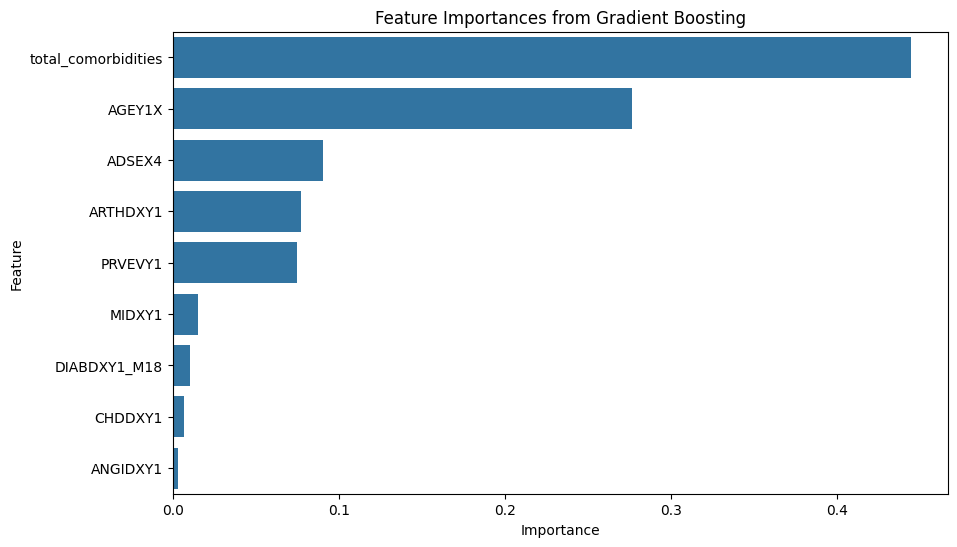

In [3]:

# Get feature importances
importances = gbr_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances from Gradient Boosting')
plt.savefig('gbr_feature_importances.png')
plt.show()


## 4. Conclusion
This notebook demonstrated how to apply a Gradient Boosting Regressor to the healthcare cost data.

The model's R-squared value indicates its predictive power on the unseen test data. Typically, Gradient Boosting outperforms Random Forests slightly, as it did here.

The feature importance plot confirms our consistent finding across all models: total_comorbidities and AGEY1X are the most significant predictors of healthcare cost rank.
    